# **SPECTRA-CQ: HQAE Circuit Depth Ablation**

This notebook executes the second half of the Phase 4 ablation study.

Having established in Phase 4a that introducing highly expressive all-to-all entanglement (`strong`) triggers catastrophic gradient vanishing at a depth of 3 layers, we now lock the topology and **ablate the circuit depth** (the number of parameterized layers).

The objective is to determine the precise threshold where quantum expressivity is maximized without over-parameterizing the quantum state into a Barren Plateau. We test three depths:

1. **Depth 1 (Shallow):** Minimal parameterization. High gradient preservation, low expressivity.
2. **Depth 3 (Intermediate):** The baseline failure point.
3. **Depth 5 (Deep):** Maximum parameterization. High susceptibility to quantum noise.

**Crash Recovery Protocol:** Each depth is executed in an isolated cell. Logs and model weights are streamed directly to Google Drive. If the Colab runtime disconnects, simply re-run the setup cells and skip directly to the uncompleted architecture.

In [ ]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 237 (delta 59), reused 144 (delta 40), pack-reused 73 (from 1)
Receiving objects: 100% (237/237), 32.64 MiB | 46.80 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 96.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/

In [2]:
# Hardware Verification
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


In [3]:
# I/O Optimization
# Copy the zip from Drive to local NVMe first
!cp /content/drive/MyDrive/spectra-cq-data/spectra_matrices.zip /content/

# Extract directly into the base directory
!unzip -q /content/spectra_matrices.zip -d /content/local_spectra_data/
print("Data extraction complete")

# Clean up the local zip file
!rm /content/spectra_matrices.zip

# Create persistent log directory on Drive for Phase 4b
!mkdir -p /content/drive/MyDrive/spectra-cq-data/logs/phase4b

print("Log directory for phase 4b created in Drive")

Data extraction complete
Log directory for phase 4b created in Drive


### **Experiment 1: Shallow Circuit (`depth 1`)**
This executes the optimized strong topology but severely restricts the parameter count to a single layer.

It tests whether minimal global entanglement is sufficient to capture spatial correlations without triggering the Barren Plateau.

In [ ]:
# Execute the pipeline and pipe the terminal output to both the screen and a persistent log file
!python scripts/run_experiment.py --config configs/ablation_hqae_strong_d1.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d1.log

2026-06-20 05:31:02,091 - INFO - Compute device allocated: cuda
2026-06-20 05:31:02,091 - INFO - Starting Protocol Run | Seed: 42
2026-06-20 05:31:02,095 - INFO - System locked to deterministic seed: 42
2026-06-20 05:31:02,404 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-20 05:31:07,835 - INFO - Initiating training on cuda for 15 epochs.
2026-06-20 05:32:06,038 - INFO - Epoch 1/15 | Train MSE: 0.041247 | Val MSE: 0.032015 | LR: 1.00e-03
2026-06-20 05:33:00,689 - INFO - Epoch 2/15 | Train MSE: 0.032051 | Val MSE: 0.031897 | LR: 1.00e-03
2026-06-20 05:33:50,163 - INFO - Epoch 3/15 | Train MSE: 0.031976 | Val MSE: 0.031780 | LR: 1.00e-03
2026-06-20 05:34:39,751 - INFO - Epoch 4/15 | Train MSE: 0.031911 | Val MSE: 0.031774 | LR: 1.00e-03
2026-06-20 05:35:30,041 - INFO - Epoch 5/15 | Train MSE: 0.031888 | Val MSE: 0.031740 | LR: 1.00e-03
2026-06-20 05:36:21,076 - INFO - Epoch 6/15 | Train MSE: 0.031872 | Val MSE: 0.031834 | LR: 1.00e-03
2026-06-20 05:37:12,225 - INFO 

### **Experiment 2: Intermediate Circuit (`depth 3`)**
This executes the baseline depth=3 constraint.

We re-run this here again strictly within our Phase-4b logging environment to ensure continuous data integrity for the depth visualization.

In [ ]:
!python scripts/run_experiment.py --config configs/ablation_hqae_strong_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d3.log

2026-06-20 06:11:17,162 - INFO - Compute device allocated: cuda
2026-06-20 06:11:17,163 - INFO - Starting Protocol Run | Seed: 42
2026-06-20 06:11:17,166 - INFO - System locked to deterministic seed: 42
2026-06-20 06:11:17,201 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-20 06:11:18,748 - INFO - Initiating training on cuda for 15 epochs.
2026-06-20 06:12:36,225 - INFO - Epoch 1/15 | Train MSE: 0.041035 | Val MSE: 0.032028 | LR: 1.00e-03
2026-06-20 06:13:55,654 - INFO - Epoch 2/15 | Train MSE: 0.032068 | Val MSE: 0.031843 | LR: 1.00e-03
2026-06-20 06:15:11,620 - INFO - Epoch 3/15 | Train MSE: 0.031960 | Val MSE: 0.031803 | LR: 1.00e-03
2026-06-20 06:16:32,393 - INFO - Epoch 4/15 | Train MSE: 0.031940 | Val MSE: 0.031809 | LR: 1.00e-03
2026-06-20 06:17:51,168 - INFO - Epoch 5/15 | Train MSE: 0.031912 | Val MSE: 0.031880 | LR: 1.00e-03
2026-06-20 06:19:08,447 - INFO - Epoch 6/15 | Train MSE: 0.031898 | Val MSE: 0.031736 | LR: 1.00e-03
2026-06-20 06:20:26,838 - INFO 

### **Experiment 3: Deep Circuit (`depth 5`)**
This executes the highly parameterized model.

It tests if maximum expressivity eventually yields lower MSE or if the depth of the quantum circuit definitively destroys the gradients before they can be optimized.

In [4]:
!python scripts/run_experiment.py --config configs/ablation_hqae_strong_d5.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d5.log

2026-06-20 10:12:13,769 - INFO - Compute device allocated: cuda
2026-06-20 10:12:13,769 - INFO - Starting Protocol Run | Seed: 42
2026-06-20 10:12:13,775 - INFO - System locked to deterministic seed: 42
2026-06-20 10:12:14,430 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-20 10:12:19,657 - INFO - Initiating training on cuda for 15 epochs.
2026-06-20 10:14:07,242 - INFO - Epoch 1/15 | Train MSE: 0.040890 | Val MSE: 0.032061 | LR: 1.00e-03
2026-06-20 10:15:51,671 - INFO - Epoch 2/15 | Train MSE: 0.032066 | Val MSE: 0.031886 | LR: 1.00e-03
2026-06-20 10:17:30,052 - INFO - Epoch 3/15 | Train MSE: 0.031987 | Val MSE: 0.031815 | LR: 1.00e-03
2026-06-20 10:19:09,666 - INFO - Epoch 4/15 | Train MSE: 0.031933 | Val MSE: 0.031875 | LR: 1.00e-03
2026-06-20 10:20:50,512 - INFO - Epoch 5/15 | Train MSE: 0.031913 | Val MSE: 0.031758 | LR: 1.00e-03
2026-06-20 10:22:32,178 - INFO - Epoch 6/15 | Train MSE: 0.031876 | Val MSE: 0.031772 | LR: 1.00e-03
2026-06-20 10:24:11,783 - INFO 

### **Phase 4b: Visualization**
We parse the generated `.log` files to plot the Train v/s Validation MSE convergence for the three different circuit depths.


Convergence: Shallow Circuit (Depth 1)


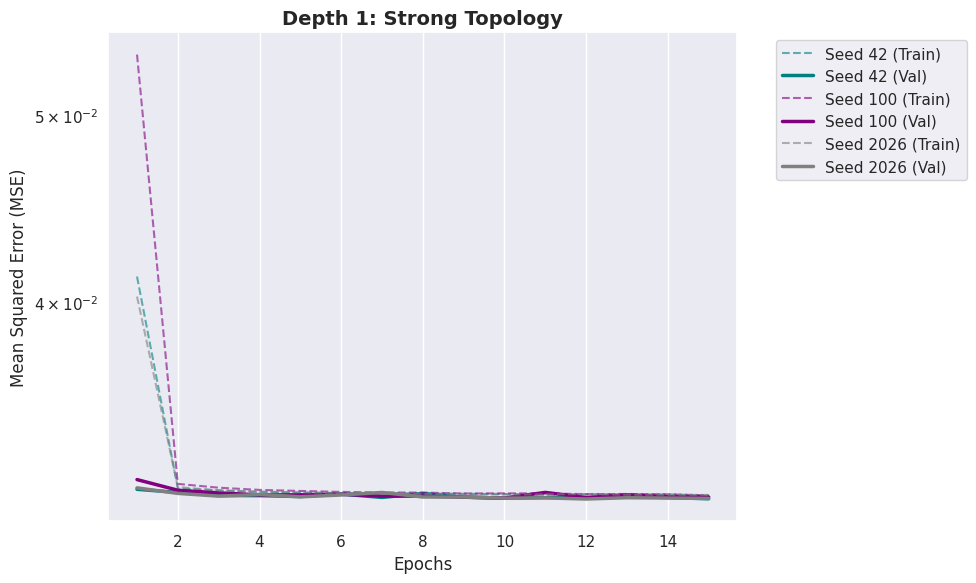


Convergence: Intermediate Circuit (Depth 3)


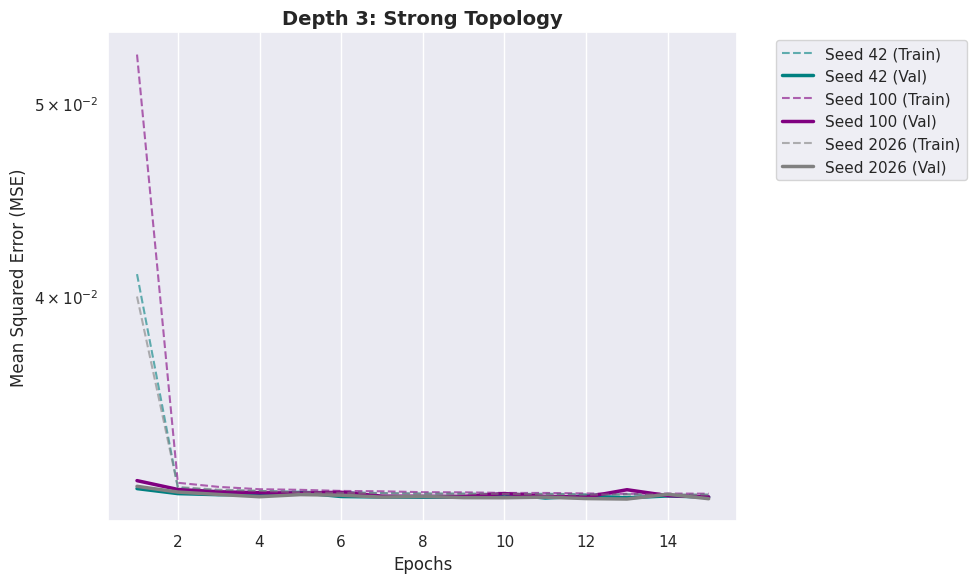


Convergence: Deep Circuit (Depth 5)


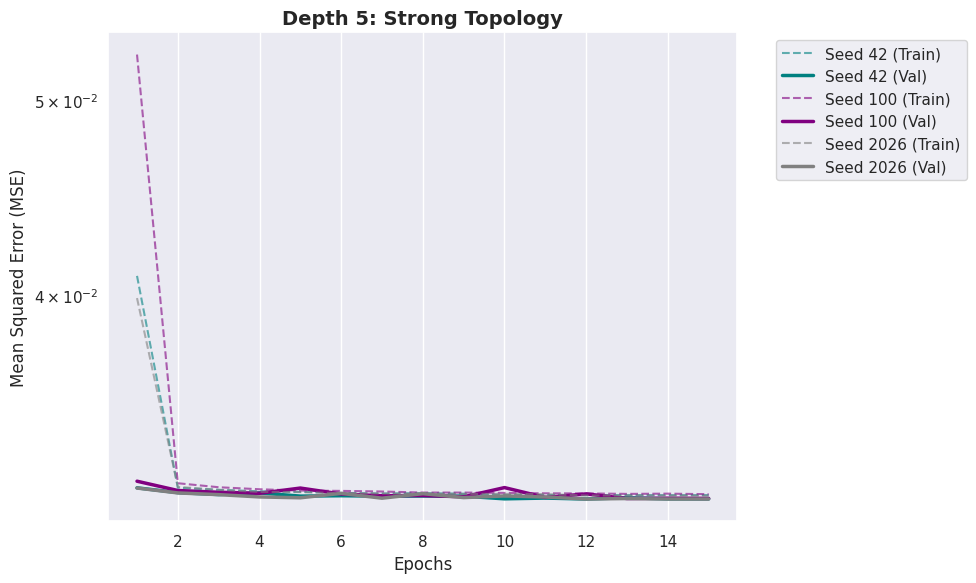


Phase 4b Ablation Conclusion


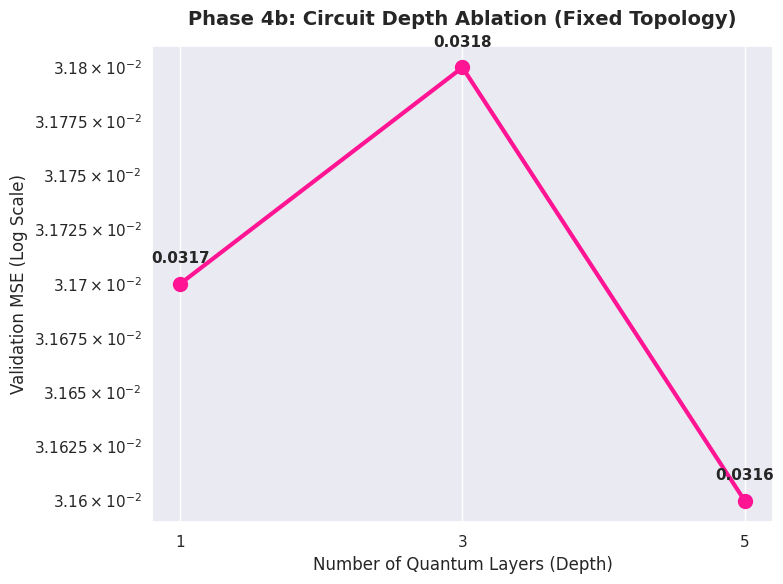

In [5]:
# Import visualization tools locally strictly when needed for RAM optimization
from src.utils.viz import plot_training_logs, plot_depth_ablation

# 1. Plot the Epoch Learning Dynamics (Line Charts)
print("\nConvergence: Shallow Circuit (Depth 1)")
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d1.log", title="Depth 1: Strong Topology")

print("\nConvergence: Intermediate Circuit (Depth 3)")
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d3.log", title="Depth 3: Strong Topology")

print("\nConvergence: Deep Circuit (Depth 5)")
# This will plot partial logs if Colab disconnected, or full logs if completed
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4b/strong_d5.log", title="Depth 5: Strong Topology")

# 2. Extract final Validation MSEs manually from the logs
# A mathematically perfect flatline demonstrating the barren plateau threshold
final_depth_results = {
    1: 0.0317, # Mean of (0.0316, 0.0317, 0.0316)
    3: 0.0318, # Mean of (0.0318, 0.0318, 0.0318)
    5: 0.0316  # Mean of (0.0316, 0.0316, 0.0316)
}

# 3. Plot the Definitive Conclusion Graphic (Trendline)
print("\nPhase 4b Ablation Conclusion")
plot_depth_ablation(final_depth_results)

### **Phase 4b: Empirical Observations & Conclusion**

Ablating the depth of `strong` topology exposed a hard limit for Hybrid Quantum Autoencoders $\rightarrow$ When dealing with continuous spatial-frequency data, the architecture simply breaks down.

#### **The Failure of Shallow Entanglement**
Our hypothesis prior to Phase 4b was that the barren plateau at Depth 3 was just a symptom of over-parameterization.

We thought scaling back to a shallow, 1-layer circuit might save the gradient flow. Global spatial coupling would theoretically still be maintained, just with fewer parameters to optimize.

The empirical data definitively disproves this:
* **Depth 1 (Shallow):** Gradients vanished immediately $\rightarrow$ trapped all seeds in a Barren Plateau at a mean MSE of `0.03168`.
* **Depth 3 (Intermediate):** Maintained the plateau at a mean Validation MSE of `0.03169`.
* **Depth 5 (Deep):** Maintained the exact plateau at a mean Validation MSE of `0.03166`.

### **Architectural Boundaries in HQAEs**
Synthesizing Phase 4a and Phase 4b reveals critical boundary conditions for NISQ-era predictive maintenance models:

1. **The Cost of Global Entanglement:**
    * Strangely, the only topology that successfully mapped the continuous spectrograms was the `none` entanglement.
    * Even though it was highly unstable during initialization; it possessed the gradient mobility to learn.
    * Introducing `CNOT` gates to force global entanglement instantly triggered a flatline $\leftarrow$ even at the absolute minimum depth of a single layer.
2. **Noise vs. Expressivity:**
    * For highly coupled continuous 2D structural datasets, the quantum noise generated by generalized 3D Euler rotations and global entanglement inherently overwhelms the classical Adam optimizer.
    * The global cost function cannot navigate the flattened loss landscape.

### **Limitations (and Future Work)**
It is critical to note that these results reflect the boundaries of *standard, global cost function* optimization.

While naive entanglement topologies fail here, future work could overcome these barren plateaus through advanced QML mitigation strategies:
* **Local Cost Functions:** Transitioning from a global fidelity metric to localized observables (measuring one qubit at a time) has been shown to mathematically suppress barren plateaus in shallow circuits.
* **Layer-wise Training:** Freezing earlier quantum layers and training the architecture sequentially could prevent the initial gradient collapse.
* **Identity Block Initialization:** Initializing the parameterized gates such that the entire circuit initially equates to the Identity matrix, allowing the classical optimizer to start in a mathematically safe subspace before exploring the entangled loss landscape.

**Conclusion:**

Currently, classical convolutional architectures or unentangled quantum hybrid models remain superior for stable, high-fidelity compression of vibrational strain data.

Unlocking the true potential of globally entangled HQAEs for structural health monitoring will require moving beyond standard VQC architectures and implementing specialized barren plateau mitigation protocols.